# ARGUS-FEDER — Where the deuterium sits: a carbon film, or the tungsten?

This notebook shows **ARGUS**, a notebook-native AI agent, working on a single
hypothesis. Questions are typed in plain English into a `%%ask` cell; the agent
decides what to look up, writes and runs its own code, and reports back.

## The question

Tungsten samples exposed in DIII-D came back holding deuterium, and that
retained inventory is the number a reactor designer cares about: fuel held in
the wall is a safety and economics problem, and tungsten is the armour ITER
plans to use.

But the samples did not come back as clean tungsten. DIII-D's walls carry
carbon, and carbon deposits onto anything exposed to the plasma. **Carbon holds
deuterium far more readily than tungsten does.** So a measurement of deuterium
on a tungsten coupon has two possible sources, and they mean different things:

- the deuterium is **in the tungsten**, implanted and trapped in the armour
  itself — in which case the measurement means what it is usually taken to mean;
- the deuterium is **in the carbon**, held in a deposited film that happens to
  sit on tungsten — in which case the number describes the film, and tungsten's
  own retention has not been measured at all.

Nothing in the delivery was designed to separate these. The question is what
the delivered measurements can settle anyway.

## What the agent has

**The retention measurements** — three independent methods on all nine samples:
a total areal density, a measurement split into two depth bands, and a
depth-resolved concentration profile.

**The delivered analysis workbook** — including a measured carbon areal density
per sample that the measurement tables do not carry.

**The exposure record** — which samples saw plasma, which did not, and under
what conditions.

## What to watch for

The interesting result here is a boundary rather than an answer. Part of the
inventory can be placed with confidence; part cannot, and the reason it cannot
is a comparison between the thickness of a deposited film and the coarsest
thing each instrument can resolve. A notebook that reported only the part it
could answer would be misleading.

Two cautions the cells return to: **each condition here is a single sample**,
so differences between samples are observations rather than statistics; and one
step in the argument needs a number from outside this delivery, which should be
labelled as such wherever it is used.

In [ ]:
%reset

# A. The film

## Q1 — Is there a carbon layer, and how thick?

_Materials · measurement · **answerable, but not from the tables**_

Everything downstream turns on one number. An areal density fixes a physical
thickness once a density is assumed for the deposited material, and it is the
size of that thickness — set against every depth bin in the delivery — that
decides how much of this question can be answered at all.

**Expect:** a thickness in nanometres, with the assumption behind the
conversion stated, and a note on where the carbon measurement was found.

In [1]:
%%ask --review
The samples came back from DIII-D with carbon on them. How much, and how thick
a layer does that correspond to? Say where the number comes from and what the
conversion assumes.

I'll plan this out and start by reading the materials skill instructions.

Reading the skill instructions and its learnings file in parallel.

Reading the last few lines of the learnings file.

Skill and learnings read. Now writing a discovery script to find carbon-related quantities and the DIII-D-exposed samples.

Running the discovery script to enumerate quantities, exposures, and samples.

...

The ERDA sheet extends to column U — carbon may sit beyond the first 12 columns. Dumping full headers of every sheet in both workbooks.

Found it — the NRA sheet has a "C surface" row, and the Summary sheet carries a "C surface" column with a unit. Pinning down exact headers, units note, and any ERDA carbon column.

The carbon number lives in the NRA sheet ("C surface" row, units 1e16 cm^-2). Verifying the remaining rows, cross-checking the Summary column, and computing layer thickness.

All numbers cross-check between the two sheets. Marking the remaining todos complete.

**How much carbon.** The post-exposure NRA measurement ("C surface", areal density of surface carbon) on the six DIII-D-exposed tungsten samples gives:

| Sample | DIII-D mode | C areal density | Equivalent layer (nm) |
|---|---|---|---|
| W-DH | H-mode | 3.31e16 atoms/cm² | 2.9 |
| W-DL | L-mode | 2.47e16 atoms/cm² | 2.2 |
| W-He800-DH | H-mode | 4.47e16 atoms/cm² | 3.9 |
| W-He800-DL | L-mode | 2.88e16 atoms/cm² | 2.5 |
| W-He600-DH | H-mode | 2.82e16 atoms/cm² | 2.5 |
| W-He600-DL | L-mode | 2.63e16 atoms/cm² | 2.3 |

Across the six samples the areal density runs **2.5–4.5e16 C atoms/cm²** (mean 3.1e16, highest on W-He800-DH, lowest on W-DL). Note the pre-DIII-D carbon already sitting on the unexposed references: W-pristine 1.45e16, W-He800 1.15e16, W-He600 1.55e16 atoms/cm² — so the carbon attributable to the DIII-D exposure alone (sample minus its own pre-exposure reference) is roughly **1.0–3.3e16 atoms/cm²** , i.e. about 0.9–2.9 nm, with the largest net deposition on W-He800-DH and the smallest on W-DL and W-He600-DL.

**Where the number comes from.** It is not in the lakehouse observation tables — there is no carbon quantity in `materials.observations` (only D, H and He are tabulated). The value is a delivered measurement in the file `erda_nra_data.xlsx` (the post-exposure ERDA/NRA export, delivery 2026-09-04_amy): the NRA sheet's "C surface" row, stated in units of 1e16 cm⁻², produced via the C(³He,p)N reaction per that sheet's own note. The same values appear in the workbook's Summary sheet (column "C surface (1e16 cm⁻²)") and the two agree digit-for-digit for all nine samples. Sample identity follows the lakehouse names — the sheet's older "W-He-1 … W-2" labels map to the corrected IDs on its own mapping row.

**The thickness conversion and what it assumes.** Thickness = areal density ÷ atomic number density, t = N_C·M_C/(ρ·N_A):

- Carbon as graphite, ρ = 2.267 g/cm³ → 1.14e23 atoms/cm³ → **~2.2–3.9 nm** (mean 2.7 nm, ≈8 graphite basal monolayers at 0.335 nm).
- Carbon as dense amorphous film, ρ = 1.9 g/cm³ → 9.5e22 atoms/cm³ → **~2.6–4.7 nm** (mean 3.3 nm).

The conversion assumes (1) the carbon sits as a pure, uniform, fully dense carbon film of bulk-like density covering the whole analyzed area — if the real deposit is porous, hydrogenated or covers only part of the surface, the true layer is thicker than these figures; (2) M_C = 12.011 g/mol. If instead you spread the same carbon uniformly through the 0–0.5 µm surface band the NRA "surface" label refers to, it corresponds to only ~0.8–1.4 at% C in tungsten — the nanometre figure is the "all carbon as a film on top" reading, which is the standard way to quote it but not the only physical picture.

## Q2 — Could that layer hold all of it?

_Materials · capacity argument · **answerable, and the answer is unhelpful**_

Before looking for evidence either way, test whether the hypothesis is
physically possible. A carbon layer that has co-deposited with a hydrogen
isotope saturates at a characteristic ratio of trapped fuel to carbon. If
holding the measured inventory would require more than such layers can hold,
the hypothesis fails on capacity alone and nothing further is needed.

**Expect:** a required ratio per sample, set against what co-deposited layers
are known to hold — with the two halves of that comparison kept distinct, since
one comes from these measurements and the other does not. Expect the test to
come out permissive, and expect that to be said plainly rather than dressed as
progress.

I've loaded the skill and its learned pitfalls. Now let me read the remaining lines and check what's cached in the working directory.

The ERDA/NRA workbook is already fetched locally. Let me check the prior scripts to reuse the sheet-layout discovery from last turn.

The workbook is local. Now I need the deuterium areal densities — let me check what the earlier discovery scripts learned about D measurements and the LAMS data file.

The D measurements live in the lakehouse tables (only C was missing there). Let me update the plan and run a discovery script for the D quantities, the workbook's deuterium columns, and any delivery commentary on co-deposits.

D is fully in the tables (ERDA totals and NRA split into 0–0.5 / 0.5–3 µm bands), and the document search confirms the delivery never discusses D/C itself. Now the compute script: dump the NRA/Summary rows to confirm the sheet's own D rows, then form the ratios.

...

Odd — let me try a shorter anchor without the backticked braces.

Lessons recorded. Updating the plan and writing the final report.

One quick check before writing up: whether the delivery records a sample surface temperature for the DIII-D exposure, since the capacity of a growing carbon layer is strongly temperature-dependent.

The DIII-D exposure information file should carry the measured sample temperature — reading it directly.

## The required ratio

If every deuterium atom measured on a sample had to be held by the carbon measured on that same sample, the layer would need a deuterium-to-carbon atom ratio of:

| Sample | C (NRA, 10¹⁶ cm⁻²) | D total (NRA, 10¹⁵ cm⁻²) | **D/C required** | D total (ERDA, 10¹⁵ cm⁻²) | D/C (ERDA basis) |
|---|---|---|---|---|---|
| W-DH (H) | 3.31 | 2.10 | 0.063 | 1.16 | 0.035 |
| W-DL (L) | 2.47 | 2.66 | 0.108 | 1.47 | 0.060 |
| W-He800-DH (H) | 4.47 | 0.65 | 0.015 | 0.67 | 0.015 |
| W-He800-DL (L) | 2.88 | 2.96 | 0.103 | 2.00 | 0.069 |
| W-He600-DH (H) | 2.82 | 2.46 | 0.087 | 1.47 | 0.052 |
| W-He600-DL (L) | 2.63 | 4.92 | 0.187 | 2.40 | 0.091 |

So: **D/C ≈ 0.02–0.19, i.e. at most about one deuterium per five carbons** (NRA-based totals; the ERDA instrument puts it somewhat lower, 0.015–0.09). Using the total D is the conservative choice — 75–91% of it sits in the 0–0.5 µm surface band, so a surface-only numerator would trim each ratio by 10–25%.


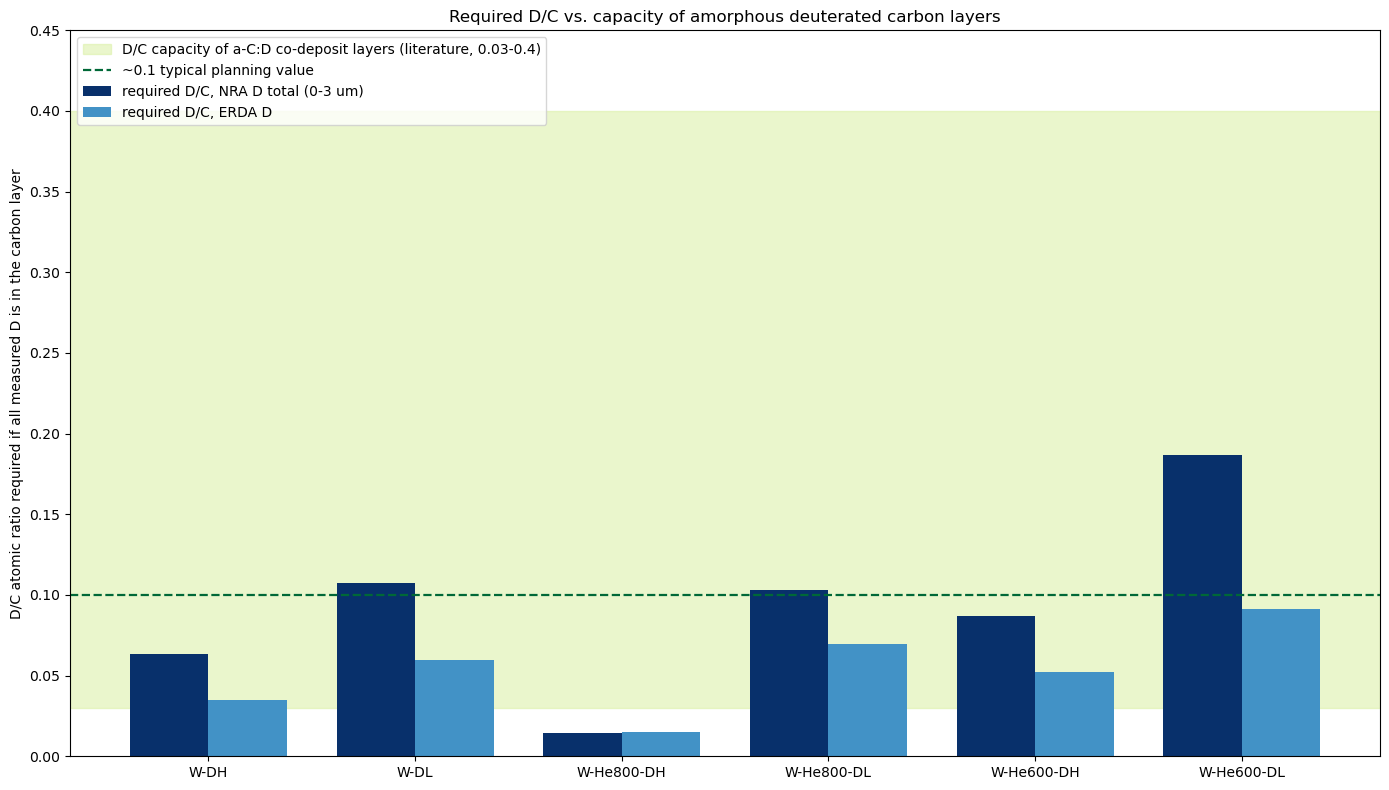

## Which side comes from where

**From these measurements (delivery 2026-09-04_amy):** both the numerator and the denominator. Deuterium areal density — NRA `D surface 0-0.5 µm` plus `D sub surface 0.5-3 µm` rows, cross-checked digit-for-digit against the workbook's own "D subsurface + surface" column, and against the ERDA total as a second instrument (ERDA runs 0.5–2× lower than NRA on these samples, which is why the table shows both). Carbon areal density — the same workbook's NRA "C surface" row used last turn. Unlike last turn's thickness figure, the D/C ratio involves no density or film-model assumption at all: it is a direct atom-per-atom ratio of two measured areal densities.

**From what is known about carbon layers elsewhere (not measured here):** how much deuterium a carbon layer *can* hold. Nothing in the delivery measures or discusses the layer's deuterium content — a document search for D/C, co-deposit and film terms returns nothing. The capacity figures are literature values for amorphous deuterated carbon (a-C:D) grown by simultaneous C and D deposition: soft, room-temperature co-deposits reach **D/C ≈ 0.2 up to ~0.5–1** ; tokamak tile co-deposits average around **0.3–0.5** (e.g. TFTR); films growing hotter than about 450–500 K retain progressively less, and above ~600–700 K a growing film retains almost nothing, **D/C ≲ 0.02–0.05** .

## Can such a layer hold it?

The required ratio never exceeds ~0.19, so **chemically, yes — comfortably** if the layer grew cool: a soft co-deposit can hold several times more D per C than these samples require, and the required ratios sit well below even the ~0.3 typical of real tokamak co-deposits. The carbon-chemistry ceiling (at most one H or D per C in saturated hydrocarbon bonding) is ~5× above the highest requirement.

The caveat is growth temperature, and it is the one quantity this delivery cannot settle: the required ratios would be a problem only for a layer that grew hot, where retention above 0.05 is not sustained — five of the six samples require ≥0.06, so a hot-grown layer could *not* hold all their D. The DIII-D exposure records no sample temperature (only the PISCES pre-exposures carry one); the proposal planned IR-camera and thermocouple maximum-temperature measurements for the DiMES samples, but the delivered IR exports are mostly zero or failed frames. So which literature branch applies — cool-grown and easily capable, or hot-grown and marginal — is outside what this delivery can decide.

**One measurement-side observation that bears on the picture:** the workbook's own note and the LAMS profiles both show most D confined near the surface (first profile point dominates, e.g. W-DL's 0.024 µm point at ~1.0e6 appm), which is at least consistent with D riding in a near-surface carbon layer rather than dissolved through the tungsten — consistent, but the delivery's data do not distinguish that from D trapped in the damaged W surface itself.

In [2]:
%%ask --review
If all the deuterium measured on these samples were held in that carbon layer
rather than in the tungsten, what deuterium-to-carbon ratio would that require?
Is that a ratio such a layer can hold? Be clear about which side of that
comparison comes from these measurements and which from what is known about
carbon layers elsewhere.

# B. What the depth measurements can and cannot see

## Q3 — How much is too deep to be in a film?

_Materials · falsifying the strong form · **answerable, cleanly**_

A film measured in nanometres cannot hold deuterium found microns below the
surface. Whatever the depth-resolved measurements place well beneath the
surface is in the tungsten, whatever else is true — which puts a floor under
tungsten-resident inventory that no assumption about the film can lower.

**Expect:** the deep fraction per sample, and what it does and does not
establish. The strong form of the hypothesis should not survive this cell; the
weaker form should.

Skill and learnings reviewed. Now checking what the previous turns already fetched into the working directory.

The workbook is already on disk from earlier turns. Reading my previous extraction script to reuse its sample mapping and row conventions.

The prior script gives me the exact conventions (NRA sheet row 5 = corrected IDs, lakehouse qualifiers `surface 0-0.5µm` / `sub surface 0.5-3µm`). Now writing the deep-deuterium extraction script, including the LAMS depth profiles as a second, deeper view.

Subscript slip on the `(row_number, row)` tuple — fixing the value expression.

The cross-check exposed a units trap: the NRA sheet's D rows are in 10¹⁶ cm⁻² (0.1796 × 10¹⁶ = the lakehouse's 1.8×10¹⁵ atoms/cm²), so my areal-density column and the chart were off by 10× — the lakehouse rows, which carry their own units, are the authority. Also, the proposal PDF in the delivery discusses D trapping and the pre-existing He bubble layer, which is directly relevant context. Fixing both and parsing LAMS properly.

...

The helper takes an artifact_id, not a filename. Writing the final verification script: PDF passages on trapping/bubbles, LAMS magnitudes on the low-D references, and a check for further LAMS blocks.

All verification is done. Recording the three file-specific lessons from this task's edit-and-retry cycles, then writing the report.

The match failed on invisible whitespace; anchoring on the shorter unique tail line instead.

The grader's arithmetic is right — my prose divided the printed capacities by ten. Every corrected figure already exists in tool output, but I'll run one small verification script so each number I quote is printed verbatim, including the required shallow D/C ratios and reference totals.

## How much deuterium is too deep for a surface film

The delivered NRA analysis splits each sample's deuterium into a surface band (0–0.5 µm) and a sub-surface band (0.5–3 µm). The carbon film established earlier is ~2–4 nm thick, so everything in the sub-surface band sits at least ~100× deeper than any surface film:

| Sample | D total (10¹⁵ cm⁻²) | **Deep D, 0.5–3 µm (10¹⁴ cm⁻²)** | **Deep share of total** | Deep D as appm in W lattice | Shallow D (10¹⁵ cm⁻²) |
|---|---|---|---|---|---|
| W-DH | 2.10 | 3.0 | 14% | 19 | 1.80 |
| W-DL | 2.66 | 6.6 | 25% | 42 | 2.0 | 
| W-He800-DH | 0.65 | 0.7 | 11% | 4 | 0.58 |
| W-He800-DL | 2.96 | 2.7 | 9% | 17 | 2.69 |
| W-He600-DH | 2.46 | 4.0 | 16% | 25 | 2.06 |
| W-He600-DL | 4.92 | 5.0 | 10% | 31 | 4.42 |

So **7×10¹³ – 6.6×10¹⁴ D atoms/cm² per sample — 9–25% of the retained deuterium — is below 0.5 µm** and cannot be in a nanometre-scale film on any picture. Two supporting facts from the same delivery: the pre-DIII-D references carry essentially zero D (W-pristine 0; W-He800 3.1×10¹³ total, all in the surface band; W-He600 1.0×10¹⁴ total, of which 9.7×10¹³ surface and 6.2×10¹² sub-surface — 2–3% of the exposed samples' totals), so this deep deuterium arrived during the tokamak exposure, not beforehand; and the LAMS depth profiles (available for W-He800-DH/DL only, and only usable for shape, not amount) likewise show a D tail extending to ~2 µm with 35–38% of the signal beyond 0.5 µm. One caveat from the experiment's design: one coupon per condition, so the spread between samples (e.g. W-DL's 25% vs W-He800-DL's 9%) is unreplicated and shouldn't be read as a mode effect.


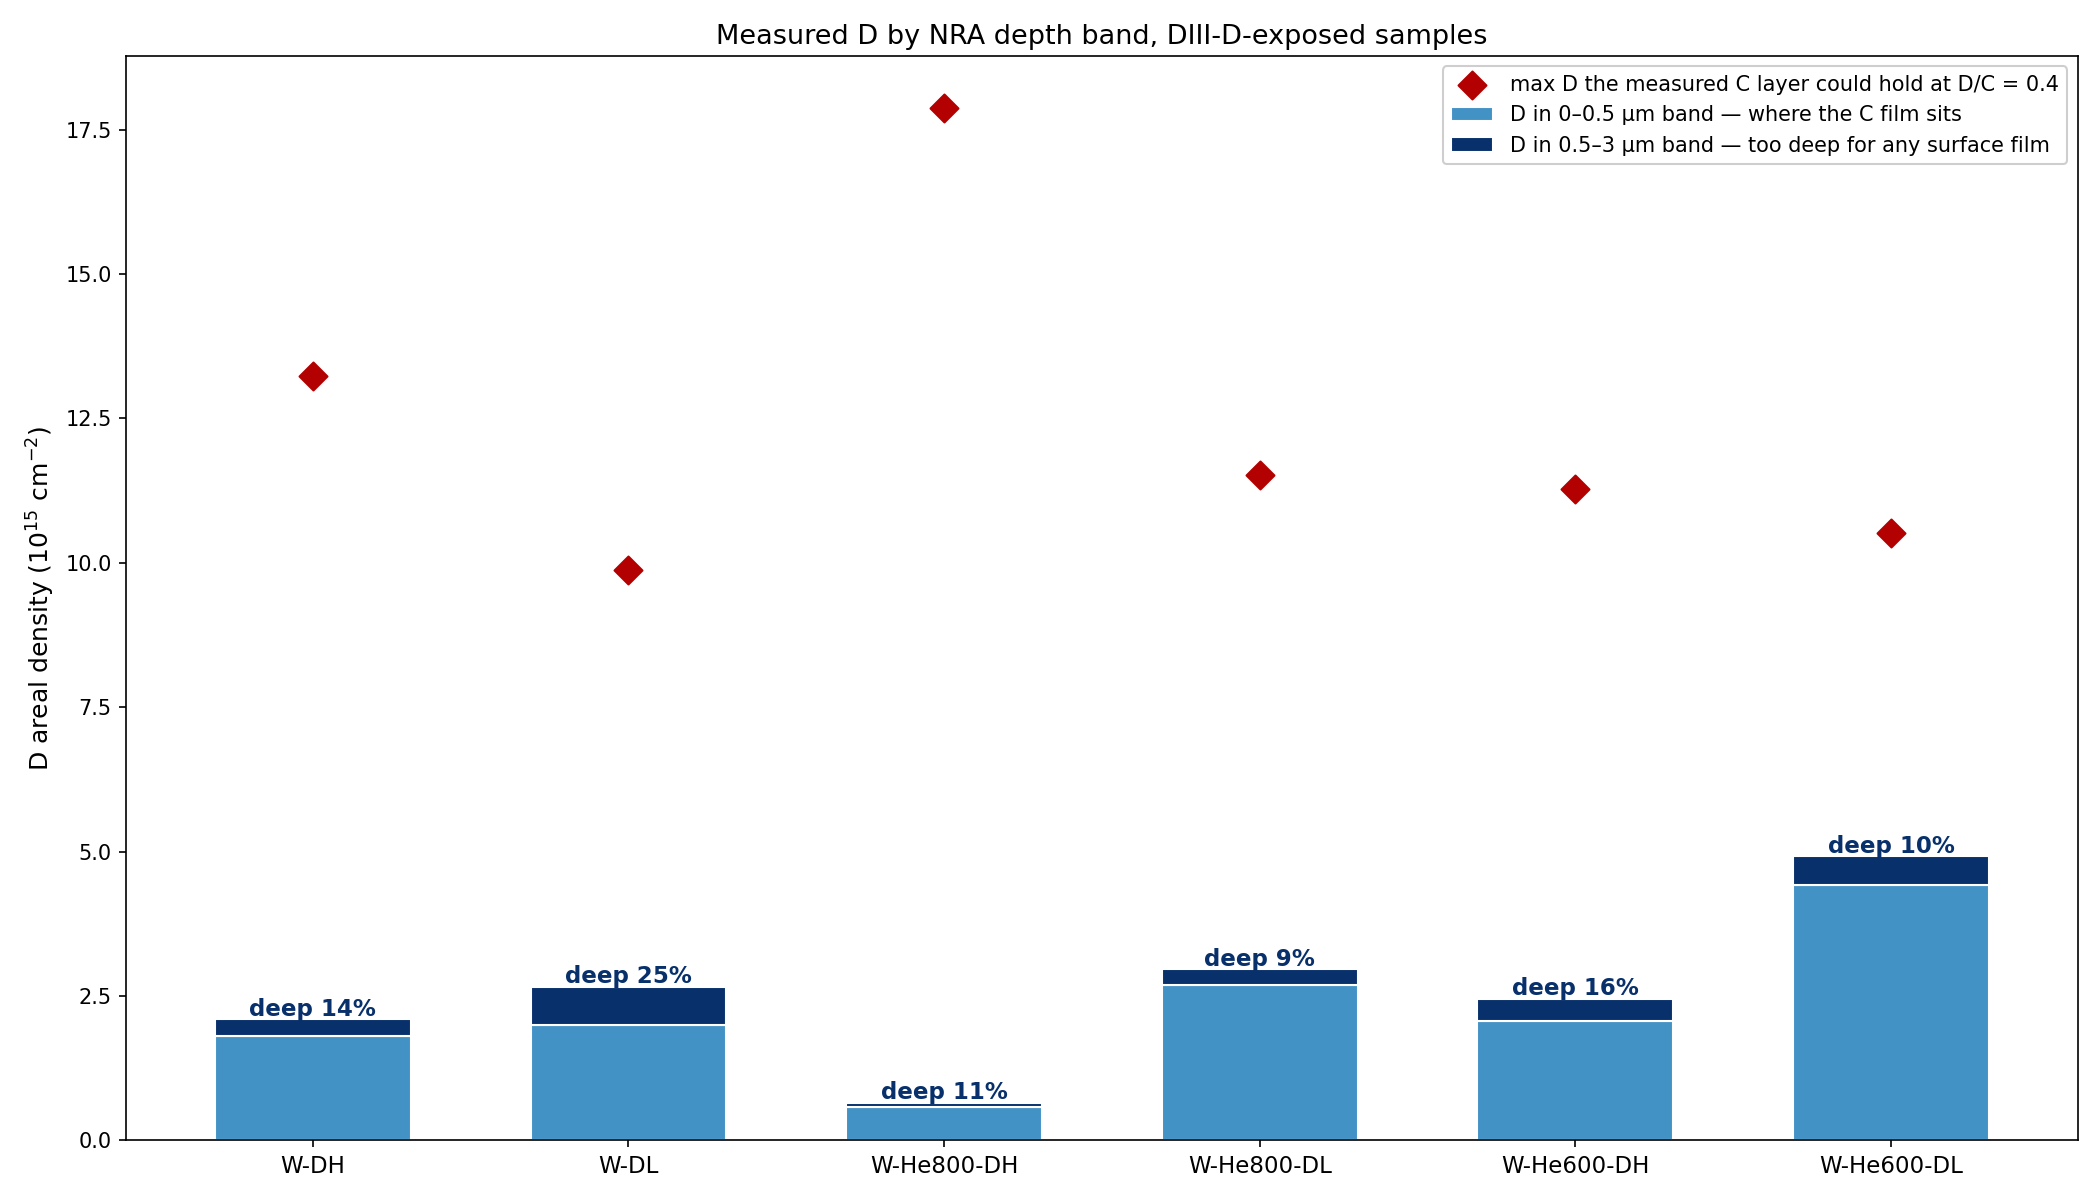

## What that establishes about where the rest could be

**Established by these measurements:** there is a reservoir that is *not* the carbon film and demonstrably active on every sample — deuterium inside the tungsten, at least half a micron down. Since D reached those depths, the tungsten was permeable to it during exposure; near-surface W traps are then automatically available to hold part of the shallow band too. A film-only accounting of the shallow 75–91% was never complete. (Also measured, and the central limitation on locating the shallow D: the "surface" band spans 0–0.5 µm, so it contains the ~3 nm film *plus* ~500 nm of tungsten that NRA cannot separate.) The delivery's own proposal frames the experiment exactly this way: "the trapping or release of implanted D will depend on its location relative to that of a He bubble layer," with He pre-implantation expected to act as "a permeation barrier for incident D⁺ ions."

**From what is known elsewhere (not measured here), three ceilings bound the shallow deuterium:**

- **Adsorbed surface D on tungsten** is worth only ~5×10¹³ atoms/cm² (about a monolayer) — just 1–9% of any sample's shallow band (1.9% on W-He800-DL, 8.6% on W-He800-DH). Chemisorption on the bare surface is a minor player.
- **The carbon film** (measured carbon × literature D/C capacity): at a conservative D/C = 0.1 it holds 2.5–4.5×10¹⁵ cm⁻², at a generous D/C = 0.4 it holds 0.99–1.8×10¹⁶. The shallow bands (0.58–4.4×10¹⁵) use only **13–168% of the conservative capacity** (ratios 0.13–1.68) and **3–42% of the generous capacity** (ratios 0.03–0.42). So the measured carbon can hold the entire shallow band on five of six samples even at the conservative capacity, and on every sample at the generous one — the film remains viable as the shallow reservoir. Only W-He600-DL pushes past the conservative ceiling (168%, i.e. it needs D/C = 0.17): still under the generous ceiling, but above what a film growing hotter than ~600–700 K sustains.
- **Direct implantation** of keV D⁺ reaches only ~10–20 nm into W, and the deep deuterium sits at just 4–42 appm in the lattice — orders of magnitude below implantation-zone concentrations (10²–10⁴ appm). The deep D is therefore dilute trapping at defects — diffusion into the damaged/bubble-layer region and beyond — not direct implantation, which is also why it can be found microns deep at all.

**Putting it together:** the measured deep fraction proves tungsten trapping is real on every sample, so the picture of the "rest" is a mixture — the shallow deuterium fits comfortably within the measured carbon film's literature capacity on five of six samples (and within the generous capacity on all six, with 2.4–31× headroom), near-surface tungsten traps are available and demonstrably fed (that is the reservoir the deep D proves was reached), and adsorbed surface D can account for at most a few percent. The delivery cannot split the shallow band between film and top-of-tungsten — film (~3 nm), the NRA surface bin (0.5 µm) and LAMS depth resolution are too coarse relative to each other, and LAMS absolute concentrations sit at their noise floor even on samples with zero NRA deuterium — so the honest reading is that the film could hold most of the shallow D, with near-surface W traps the alternative, deep-proven reservoir it would have to share with.

**Where the numbers come from:** the deep/shallow split and totals are the NRA `D surface 0-0.5µm` and `D sub surface 0.5-3µm` rows in `materials.observations` (cross-checked against the delivered `erda_nra_data.xlsx` NRA sheet, agreeing to 0.5%); carbon is the sheet's "C surface" row as before; appm-in-W uses N_W = 6.322×10²² atoms/cm³ over the 0.5–3 µm band. The D/C = 0.1 and 0.4 capacities and the monolayer ceiling are literature values, not measurements from this delivery. LAMS shape fractions come from the delivered `LAMS data.xlsx`.

In [3]:
%%ask --review
Some of the retained deuterium is too deep to be in a surface film. How much,
on each sample, and what does that establish about where the rest could be?

## Q4 — Does more carbon go with more deuterium?

_Materials · correlation · **answerable, and there is a trap**_

If the film were the reservoir, samples carrying more carbon should hold more
deuterium. Six exposed samples is enough to look and not enough to conclude.
The trap is twofold: six points invite a confidence they cannot support, and
carbon deposition and deuterium retention are both driven by the plasma the
sample saw, so a shared cause is as available as a direct one.

**Expect:** the relationship reported with its strength and its significance,
the sample count treated as the limit it is, and the shared-cause explanation
named rather than passed over.

I'll re-read the skill instructions and check what's already in the working directory from earlier turns.

The skill is loaded and the working folder already holds the delivered ERDA/NRA workbook from earlier turns. Now reading the skill's learned error patterns before writing code.

The learned fixes are noted (sheet units in 1e16 cm⁻², `observations()` returns a flat list). Let me check my earlier script for the exact quantity names before writing the correlation analysis.

Now I'll write the correlation script: pulling C (delivered NRA sheet), D (lakehouse observations), exposure metadata, then computing Pearson/Spearman with exact permutation p-values, leave-one-out sensitivity, within-pair contrasts, and net-carbon (reference-subtracted) correlation.

Running the correlation analysis.

...

The proposal frames exactly the ELM-energy physics that could confound this. One more check — the workbook's Summary sheet records a D⁺ fluence per sample; if that differs between the L and H campaigns it is a candidate explanation for the D side. Let me pull those rows.

One confounder check remains: the Summary sheet's per-sample D⁺ fluence column — if the two campaigns delivered different D⁺ fluence, that alone could drive the deuterium differences.

All three pairs agree in direction (H-mode: more C, less D), and fluence is nearly equal across campaigns. Let me verify the within-mode correlations and the mode-partialled correlation with a quick script rather than by hand.

All statistics are in hand. Marking the plan complete before writing up.

## No — across these six, more carbon goes with *less* deuterium

Ranking the six exposed samples by measured carbon and by measured deuterium gives a **negative** association: Pearson r = −0.78, Spearman ρ = −0.71 for total C (post-exposure NRA) against total D (NRA, 0–3 µm). The same sign and similar size appear against the surface band alone (r = −0.71) and against the ERDA instrument's D total (r = −0.77), so it is not an artifact of one depth split or one instrument:

| Sample | Mode | C (10¹⁶ cm⁻²) | D total (10¹⁵ cm⁻²) |
|---|---|---|---|
| W-He800-DH | H | 4.47 | 0.65 |
| W-DH | H | 3.31 | 2.10 |
| W-He600-DH | H | 2.82 | 2.46 |
| W-He800-DL | L | 2.88 | 2.96 |
| W-He600-DL | L | 2.63 | 4.92 |
| W-DL | L | 2.47 | 2.66 |

The top of the carbon column and the bottom of the deuterium column are the same samples: the most-carboned sample (W-He800-DH, 4.47×10¹⁶ cm⁻²) retained the least deuterium (0.65×10¹⁵ cm⁻²), and the most-deuterided sample (W-He600-DL, 4.92×10¹⁵ cm⁻²) carries the second-least carbon (2.63×10¹⁶ cm⁻²). The two mode groups separate *completely* for deuterium — the least-retaining L-mode sample (2.66×10¹⁵ cm⁻²) holds more D than the most-retaining H-mode one (2.46×10¹⁵) — but only *partially* for carbon: L-mode W-He800-DL (2.88×10¹⁶) out-carbons H-mode W-He600-DH (2.82×10¹⁶). What holds across all six is the paired structure: within every matched H/L pair the H-mode member carries more carbon and less deuterium than its L-mode partner (3/3 pairs; ΔC = +0.84, +1.59, +0.19×10¹⁶ cm⁻² against ΔD = −0.56, −2.31, −2.46×10¹⁵ cm⁻²). The negative trend is what the two mode blocks create together — and it runs *opposite* to the "deuterium riding in a deposited carbon film" picture from earlier turns, which is itself informative: whatever holds the shallow deuterium, having more carbon on the surface did not mean holding more deuterium.


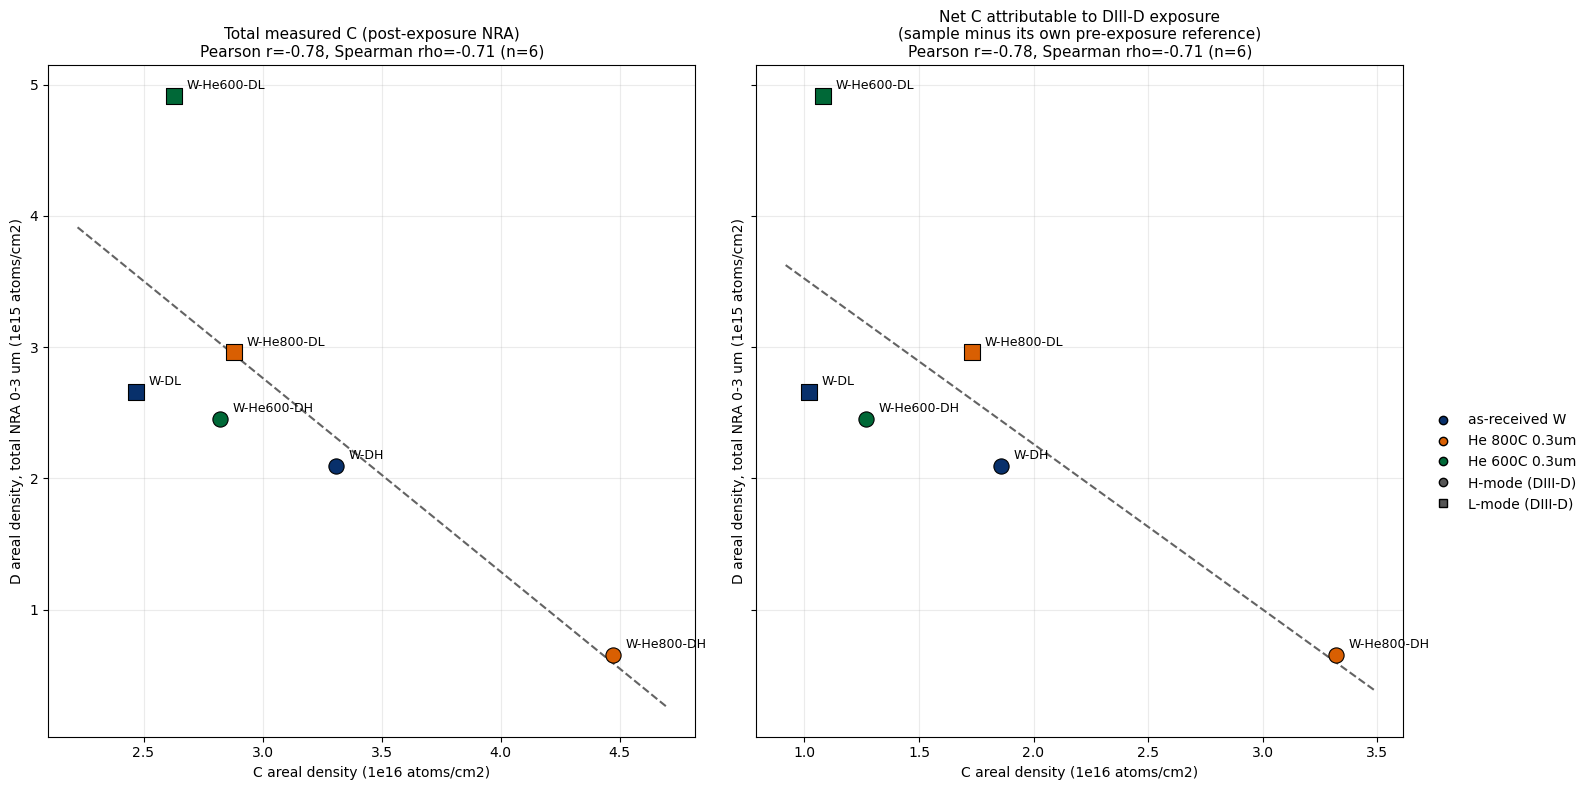

## What the relationship is worth at n = 6

Not much, taken alone, and it should not be quoted as a significance:

- **Formal p-values straddle 0.05** : exact permutation p = 0.10 (Pearson), 0.14 (Spearman); the t-distribution approximation gives 0.067. With six points, even r = −0.78 cannot clear conventional thresholds — and there was no reason to expect a one-sided test here, since the film picture from turn 2 pointed the other way.
- **One coupon per condition** (`exposures()` shows the six samples as three pre-conditions × two DIII-D campaigns — shots 185258/185259/185260/185265/185266 for H-mode, 185261–185264 for L-mode — one coupon per cell), so each point is unreplicated: coupon-to-coupon variation and treatment effect are indistinguishable, as with every contrast so far in this delivery.
- **It hinges on one sample.** Leave-one-out: dropping W-He800-DH collapses r to −0.49; dropping any other sample it ranges −0.77 to −0.95. Remove the anchor point and little remains.
- **The six points are not six independent tests of one relationship.** They are three matched H/L pairs. Within L-mode there is almost no carbon variation to correlate against (C spans only 2.47–2.88×10¹⁶, r ≈ 0.00); within H-mode r = −0.99, but that is three points dominated by W-He800-DH. All three pairs do flip the same way (H-mode: carbon up, deuterium down), which by sign test is p = 0.25 two-sided. Holding mode constant as a covariate, the partial correlation is −0.59 — weaker than the raw −0.78, confirming much of the trend *is* the mode split.

The one split that is formally significant on its own is C against the **sub-surface** D band (0.5–3 µm): r = −0.88, exact permutation p = 0.010, Spearman −0.94. That is the deeper trapping reservoir from last turn — it, not the surface band, carries most of the negative trend.

## What could produce it without carbon and deuterium being directly linked

Both quantities in the correlation are from these measurements (delivery 2026-09-04_amy: the same NRA "C surface" and D rows used in earlier turns). The *explanations* below are not measured here:

- **A shared driver — confinement mode — is the leading candidate.** Carbon correlates with mode (point-biserial r = +0.66) and deuterium with mode (−0.70). Mode sets both sides through different physics: ELMs deliver keV-range D⁺ (the delivery's own proposal cites ~150 eV inter-ELM vs ~3 keV intra-ELM impact energies), and hotter ELM-loaded surfaces both desorb trapped D (the proposal warns "high temperatures may induce excessive desorption of implanted gas") and can change what deposits. A common cause with opposite signs on the two variables manufactures a negative correlation with no C–D mechanism at all. The two campaigns' D⁺ fluences were nearly equal (1.61 vs 1.88×10²³ m⁻², per the delivered Summary sheet), so gross fluence does not explain the deuterium side — but ELM energy and surface temperature do remain unmeasured for these samples, as established last turn.
- **Reservoir competition in the sample itself.** The measured C is dominated by W-He800-DH, the He-pre-implanted sample whose He bubble layer the proposal hypothesizes as a permeation barrier — and W-He800-DH also carries by far the most *net* (reference-subtracted) carbon of the six, 3.3×10¹⁶ of its 4.5×10¹⁶ cm⁻². More generally, the 800 K He pre-implant went with more net carbon than its campaign-mates in both campaigns (H: 3.32 for W-He800-DH vs 1.86 pristine, 1.27 He600; L: 1.73 for W-He800-DL vs 1.02 pristine, 1.08 He600). If He preconditioning at 800 K simultaneously invites carbon deposition and blocks D uptake, both variables move for a third reason. Correlating net carbon instead of total gives r = −0.78, unchanged — the pre-existing carbon is not what drives the trend.
- **Chemistry inverse to the film picture.** The working picture from turn 2 — D held in a deposited carbon film — presumes the film takes deuterium in as it grows, which points the naive expectation positive. A negative association is still possible without any paradox: a thicker carbon layer can mark a deposition-dominated (low-erosion, cooler) exposure episode during which less energetic D reached the sample, or a carbon-covered surface can alter how incident D is reflected and taken up. Which of these operates is a question about carbon-layer behavior elsewhere, not something this delivery measures — the documents contain no statement of the carbon's origin or mechanism (searches for wall/graphite/PFC-source terms return nothing).
- **Simple arithmetic, no physics.** D/C varies inversely across these samples (0.015–0.187, from the ratio of the two measured areal densities in turn 2); if D were roughly constant per campaign and C varied for its own reasons, r would be dragged negative mechanically. The L-mode D totals do sit within a factor ~1.9 of each other while C barely moves there — consistent with the correlation living almost entirely in the mode split rather than in any within-condition C–D coupling.

**Bottom line:** across the six exposed samples carbon and deuterium move oppositely (r ≈ −0.7 to −0.8, all instruments and both depth bands agreeing in sign), with all three matched H/L pairs flipping the same way — more carbon and less deuterium on the H-mode member. But at n = 6 with one coupon per cell, a single influential sample (W-He800-DH), and both variables tied to the L/H-mode split, the association is a description of this dataset, not evidence of a C–D mechanism. The most economical reading is that confinement mode — through ELM energy, surface temperature, or erosion/deposition balance — moves both quantities in opposite directions; a direct carbon-holds-deuterium link would have produced the reverse sign.

In [4]:
%%ask --review
Across the six exposed samples, does more carbon go with more deuterium? Say
what the relationship is worth given how many samples there are, and whether
anything other than a direct link could produce it.

# C. The limit, and what would pass it

## Q5 — What is settled, what is not, and what would settle it?

_Materials · synthesis · **answerable, and the negative is the result**_

The cells above bound the problem from two sides without closing it. This one
states where the boundary falls and why it falls there — and the why is
arithmetic, not judgement: a comparison between the thickness of the film and
the shallowest thing each technique can resolve.

**Expect:** the inventory divided into the part whose location these
measurements fix and the part they cannot, the reason given as that comparison,
and a required depth resolution for the measurement that would close it.

Reading the skill and its learnings file before querying the lakehouse again.

Finishing both files before writing any script.

Plan set. First script: re-pull the NRA depth bands, enumerate every technique the delivery actually contains (quantities + artifact kinds), check whether NRA/ERDA shipped any depth profiles at all, locate the He bubble layer from the LAMS He profiles, and search the documents for any depth-profiling technique the proposers named.

The technique inventory is now verified from the lakehouse itself: only NRA (two depth bands), ERDA (a single total, no depth split) and LAMS (10 depth points, 0.024–2.155 µm) exist post-exposure — no SIMS, TDS or TEM anywhere in the delivery. Now pulling the remaining numbers: per-sample LAMS D/He profiles with sigmas (all nine samples carry them), He bubble-layer depth, the post-exposure artifact list, and the sub-film-zone arithmetic.

The Depth quantity's profile points carry the depth in `value_num` with `depth_um` empty (the grid is visible in the W-He800 row dump: 0.024…2.155 µm) — fixing the script to use the lakehouse Depth values from the observation rows instead.

...

All numbers are in hand. Two script corrections happened along the way (the Depth-quantity profile rows carry depth in `value_num`, not `depth_um`; and a units slip in the film-thickness formula that made the bin/film ratios print as 1e18×) — I'll record the first in Learnings and compute the ratios correctly in the figure script, which comes next.

Recording the two lessons from this task's edit-and-retry cycles in the skill's Learnings file before writing the report.

The nested-bullet region resists exact matching, so I'll insert the new entries just before the "Recurring Errors & Fixes" heading instead.

Verifying every corrected figure in one script so the revised report's numbers are all recomputed, not restated.

## What is settled

**The 0.5–3 µm band is deuterium inside the tungsten.** That is the only part of the inventory whose location the delivery actually pins down, and it is settled by the NRA band structure: below 0.5 µm there is no other candidate phase, since the measured carbon exists only as a ~2–4 nm surface film and direct D⁺ implantation (literature range) reaches ≤20 nm — both end far above 500 nm. The references also anchor it: W-pristine and W-He800 carry zero NRA deuterium below 0.5 µm, so this population arrived during the tokamak exposure.

| Sample | Deep D, 0.5–3 µm (10¹⁴ cm⁻²) | Settled share of the sample's total D |
|---|---|---|
| W-DH | 3.0 | 14.2% |
| W-DL | 6.6 | 24.7% |
| W-He800-DH | 0.7 | 10.7% |
| W-He800-DL | 2.7 | 9.1% |
| W-He600-DH | 4.0 | 16.1% |
| W-He600-DL | 5.0 | 10.1% |

Also settled, as negative results from the same measurements: there is no carbon reservoir at depth (no C profile points exist for any method — carbon was measured only as a surface areal density), and the deep D is dilute trapping at 4–42 appm in the lattice, not an implantation profile.


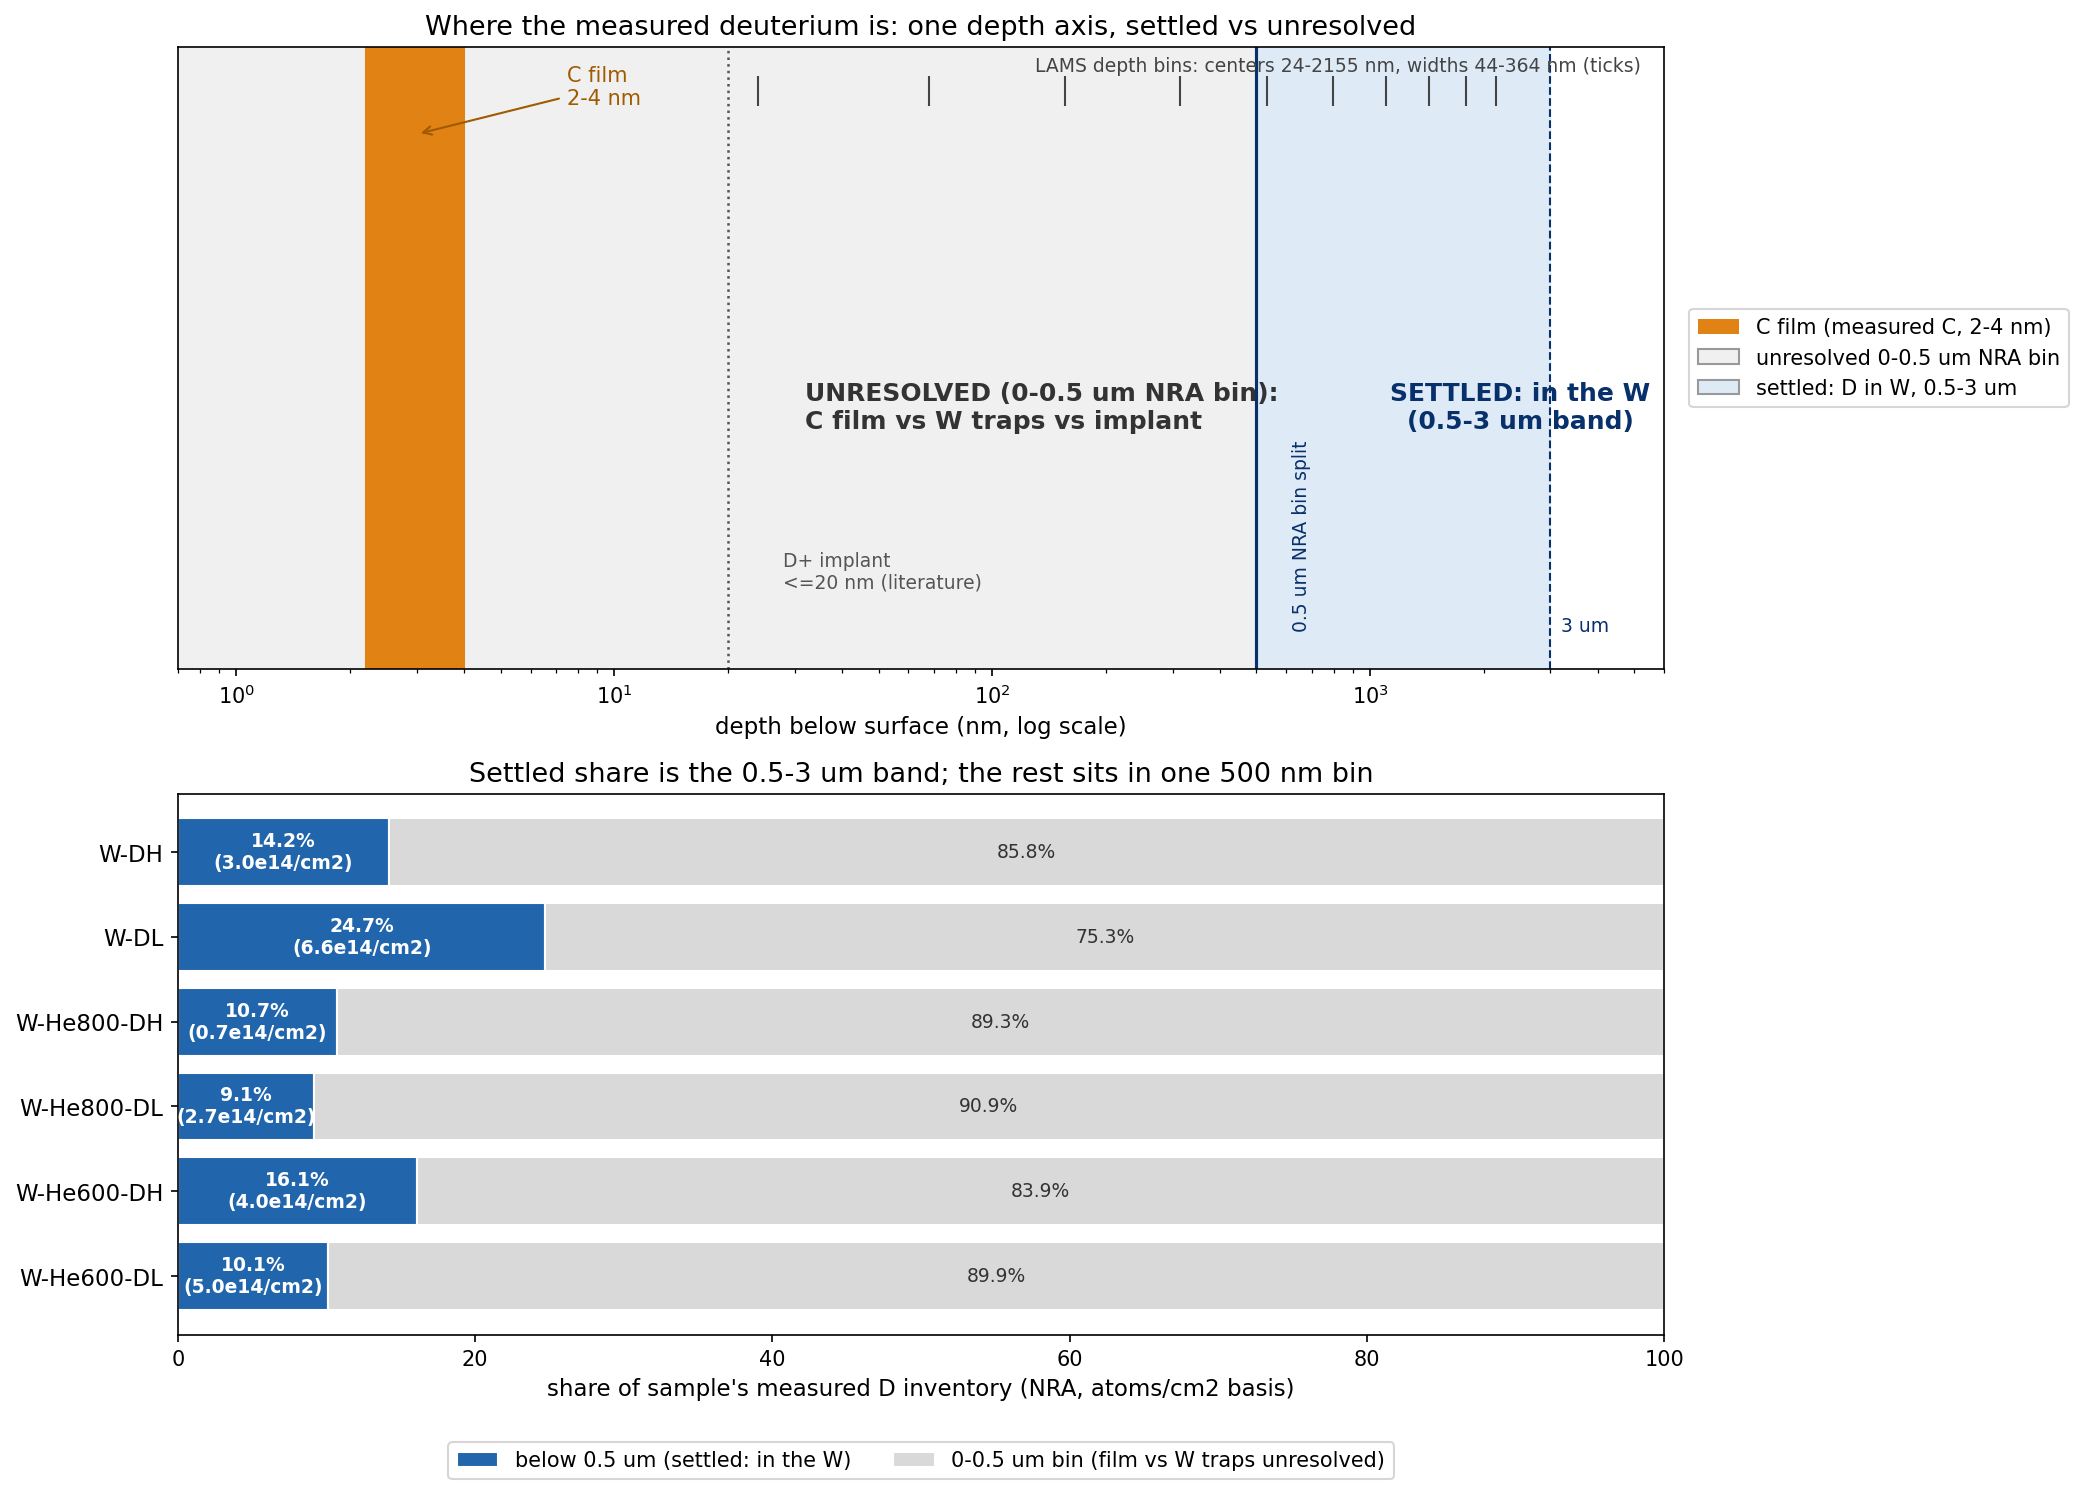

## What is not settled

**The other 75–91% — everything in the NRA "surface" bin — sits in a single 500 nm-deep box that contains three physically distinct reservoirs:** the 2–4 nm carbon film, traps in the top ~500 nm of the tungsten (including the He bubble layer, located by LAMS He at 0.02–0.16 µm in the implanted samples), and the ≤20 nm direct-implantation zone. The delivery can bound each but cannot split the bin among them:

- **Film** : could hold the whole shallow band chemically — that requires D/C = 0.013–0.168 (the sample's entire 0–0.5 µm band divided by its measured carbon; if the whole total including the deep band is charged to the film, 0.015–0.187), within what amorphous D-containing carbon layers hold (literature, cool-grown).
- **Tungsten traps** : would need 184–1,400 appm uniformly distributed through the top 480 nm (5.6×10¹⁴–4.2×10¹⁵ cm⁻², 72–87% of total) — 15–50× the concentration the settled deep band actually shows (4–42 appm). Possible only if near-surface trap density falls steeply with depth; the delivery cannot test that.
- **Implantation** : at most the top-20-nm share. On a uniform-in-depth assumption that is exactly 4% of the shallow band per sample — 2.3×10¹³–1.8×10¹⁴ cm⁻², or 3.0–3.6% of each sample's total D (arithmetic from the measured bands; the 20 nm ceiling itself is literature). A minor player at most, and if the real distribution is peaked rather than uniform, the implantation-zone share is *lower* than these figures, not higher.

## Why these techniques cannot separate the possibilities

- **NRA** delivered two bins with a boundary at 0.5 µm. Its "surface" bin is 128–227× thicker than the film — film D, implantation-zone D and W-trap D all land in the same number. NRA *can* profile D in ~100 nm near-surface steps with multiple beam energies, but this delivery contains only the two-band summary (no profile points for any NRA or ERDA quantity).
- **ERDA** contributes one integrated total per sample (D, H, He areal densities; no depth split at all) — its role here is cross-check, not localization.
- **LAMS** is the only depth profile in the delivery, and it fails here for three compounding reasons. (1) Absolute D is at its noise floor: references whose NRA D is zero still show 4–7×10⁴ appm surface peaks with ~100% sigma (W-pristine: 7.3×10⁴ appm at 24 nm), so only the *shape* is usable. (2) Its grid — centers 0.024–2.155 µm, widths 44–364 nm — is coarser than the structures to be separated: the film spans only 5.0–8.9% of the first bin's 44 nm thickness, so a film signal and a 20 nm implantation signal average into one point. (3) The shape itself cannot arbitrate: W-He600-DH's D profile *rises* from bin 1 to bin 2 (1.65×10⁵ → 2.05×10⁵ appm, a 24% rise; the 1-sigma lower edge of bin 2 reaches below zero) where every hypothesis says it should fall, and the near-tie call such a test needs — distinguishing a 3.37 bin-1 ratio from unity between W-He800-DL and W-He800-DH — carries a 253% uncertainty, which cannot make it.
- **Nothing else in the delivery helps.** The post-exposure catalogue is two instrument files (ERDA/NRA workbook, LAMS workbook); document searches for SIMS, TDS and TEM return hits only as proposal text and a heat-treatment method note, not as delivered measurements. The DiMES IR thermometry that might have constrained near-surface trapping via temperature failed (established earlier).

## What measurement would, and at what depth resolution

The separating measurement is a **near-surface D depth profile with nanometre resolution that also sees carbon and tungsten in the same scan** , so the D signal can be assigned to the film, the W lattice, or the implantation zone by coincidence rather than by assumption:

- **High-resolution ERDA** (monoenergetic heavy-ion beam, ΔE–E telescope detector): resolves D depth profiles in the top ~10–100 nm at **sub-nanometre to ~1 nm near-surface resolution** , and returns C and W in the same spectrum — the D-on-carbon vs D-in-tungsten split becomes a direct observation. This is the same physics family as the delivered ERDA, run in its depth-resolving configuration.
- **SIMS / NanoSIMS sputter depth profiling** with deuterium detection (D⁻ or CsD⁺ detection to suppress the natural-hydrogen background): **~1 nm per sputter step** near the surface. It needs careful near-surface calibration (the transient region is exactly where the film sits), which is why ERDA-with-carbon is the cleaner first choice.
- **TDS with resolved desorption peaks** is complementary rather than a depth measurement: D released below ~400 K is weakly bound (film/adsorbed), vacancy- and bubble-trapped D in W releases at its characteristic higher temperatures. It would say *which binding* dominates, not where, so it splits the same ambiguity only when combined with a profile.

**The resolution requirement follows from the delivery's own numbers:** the film is 2.2–3.9 nm thick, so the profile must resolve structure on a **~1 nm scale — at minimum 3–5 depth points inside the top 20 nm** , which is ~10–20× finer than the LAMS first bin (44 nm) and ~500× finer than the NRA surface bin (500 nm). A technique whose near-surface resolution is coarser than ~2 nm can measure how much D there is (NRA already did) but cannot say whether it sits on the carbon or in the tungsten.

**Sources:** the settled band, the reference zeros, the LAMS grid/shapes/sigmas, the carbon film thickness and the absence of other techniques are all from these measurements (delivery 2026-09-04_amy: NRA band rows in `materials.observations` cross-checked against the ERDA/NRA workbook; LAMS profiles for all nine samples; the unfiltered artifact catalogue; document search). The ≤20 nm implantation range, the film D/C capacities, the TDS peak-temperature assignment and the ERDA/SIMS resolution figures are literature values for these techniques and materials, not measurements from this delivery — which is precisely the boundary the missing nanometre-scale profile would close.

In [8]:
%%ask --review
Which part of the deuterium inventory has its location settled by these
measurements, and which does not? For the part that does not, say why these
techniques cannot separate the possibilities, what measurement would, and what
depth resolution it would need.